In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPUs: ", tf.config.list_physical_devices('GPU'))

2026-02-25 07:05:51.009150: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772003151.245835      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772003151.316216      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772003151.863903      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772003151.863946      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772003151.863950      55 computation_placer.cc:177] computation placer alr

Num GPUs Available:  2
GPUs:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
fake=pd.read_csv("/kaggle/input/datasets/bhavikjikadara/fake-news-detection/fake.csv")
true=pd.read_csv("/kaggle/input/datasets/bhavikjikadara/fake-news-detection/true.csv")

In [4]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [6]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [8]:
fake.drop(columns=['subject','date'],inplace=True)

In [9]:
true.drop(columns=['subject','date'],inplace=True)

In [10]:
fake.head()

,title,text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk..."
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ..."
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...


In [11]:
true.head()

,title,text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...


In [12]:
fake['label']=0

In [13]:
fake.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [14]:
true['label']=1

In [15]:
true.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [16]:
data=pd.concat([true,fake],ignore_index=True)

In [17]:
data=data.reset_index(drop=True)

In [18]:
data.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   44898 non-null  object
 1   text    44898 non-null  object
 2   label   44898 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [20]:
data.sample(10)

,title,text,label
39236,LOL! HILLARY Commends Weinstein Accusers For C...,Hillary Clinton today falsely called Donald Tr...,0
29745,Someone Added Up The Money The Rich Have In O...,You ve heard about those offshore accounts the...,0
6557,Obama to meet lawmakers in attempt to protect ...,WASHINGTON (Reuters) - President Barack Obama ...,1
38608,MOOCH’S TRIP TO CHINA RAN TAXPAYERS MORE THAN ...,The whole premise of promoting education is su...,0
9674,Trump signals willingness to raise U.S. minimu...,(This version of the story corrects the figur...,1
7252,U.S. says war crimes probe of U.S. forces in A...,WASHINGTON (Reuters) - An International Crimin...,1
43843,Clinton’s ‘No-Fly Zone’ over Syria Will Not “S...,Prof Michel Chossudovsky Global ReaseachThe me...,0
20031,Japan's Suga: government strongly protests lat...,TOKYO (Reuters) - North Korea fired a ballisti...,1
35630,LIBERAL “The View” HOSTS MOCK HILLARY’S RESPON...,Hell begins freeze over Did We Ever Think That...,0
43807,E.T. Williams Explains Why Millennials are in ...,21st Century Wire says Donald Trump s victory ...,0


In [21]:
import re
import string


In [22]:
english_punctuations = string.punctuation

In [23]:
import nltk

In [24]:
from nltk.corpus import stopwords
stopwords_en = set(stopwords.words('english'))

In [25]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet


In [26]:
lemmatizer = WordNetLemmatizer()

In [27]:
# pip install rapidfuzz


In [28]:
# from rapidfuzz import process


In [29]:
from tqdm import tqdm

In [30]:
import emoji

In [31]:
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("wordnet")

[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [32]:
data.head(2)

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1


In [33]:
for col in ['title','text']:
    data[col]=data[col].str.lower()

In [34]:
data.head()

,title,text,label
0,"as u.s. budget fight looms, republicans flip t...",washington (reuters) - the head of a conservat...,1
1,u.s. military to accept transgender recruits o...,washington (reuters) - transgender people will...,1
2,senior u.s. republican senator: 'let mr. muell...,washington (reuters) - the special counsel inv...,1
3,fbi russia probe helped by australian diplomat...,washington (reuters) - trump campaign adviser ...,1
4,trump wants postal service to charge 'much mor...,seattle/washington (reuters) - president donal...,1


In [35]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [36]:
import contractions

In [37]:
for col in ['title','text']:
    data[col]=data[col].apply(lambda x: contractions.fix(x))

In [38]:
#remove urls

In [39]:
for col in ['title','text']:
    data[col]=data[col].str.replace(r"http\S+|https\S+|www\S+","",regex=True)

In [40]:
#remove punctuation

In [41]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [42]:
for col in ['title','text']:
    data[col]=data[col].str.replace(f"[{string.punctuation}]","",regex=True)

In [43]:
pip install symspellpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 31.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 11.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [44]:
filename="/kaggle/input/datasets/jasonheesanglee/symspell-677/frequency_dictionary_en_82_765.txt"

In [45]:
from symspellpy import SymSpell, Verbosity

In [46]:
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

# Load dictionary file
sym_spell.load_dictionary(filename, 0, 1)

True

In [47]:
def correct_sentences(text):
    try:
        suggestion=sym_spell.lookup_compound(str(text),max_edit_distance=2)
        return suggestion[0].term if suggestion else text
    except:
        return text
        

In [48]:
#data['corrected_text']=data['text'].apply(correct_sentences)

In [49]:
from tqdm import tqdm
tqdm.pandas()

In [50]:
data['corrected_text'] = data['text'].progress_apply(correct_sentences)

100%|██████████| 44898/44898 [1:14:39<00:00, 10.02it/s]


In [51]:
data.head()

,title,text,label,corrected_text
0,as yous budget fight looms republicans flip th...,washington reuters the head of a conservative...,1,washington reuters the head of a conservative ...
1,yous military to accept transgender recruits o...,washington reuters transgender people will be...,1,washington reuters transgender people will be ...
2,senior yous republican senator let mr mueller ...,washington reuters the special counsel invest...,1,washington reuters the special counsel investi...
3,fbi russia probe helped by australian diplomat...,washington reuters trump campaign adviser geo...,1,washington reuters trump campaign adviser geor...
4,trump wants postal service to charge much more...,seattlewashington reuters president donald tr...,1,seattle washington reuters president donald tr...


In [52]:
data.drop(columns=['text'],inplace=True)

In [53]:
def remove_stopwords(text):
    words=text.lower().split()
    filtered=[words for word in words if word not in stopwords_en]
    return filtered

In [54]:
data.head()

,title,label,corrected_text
0,as yous budget fight looms republicans flip th...,1,washington reuters the head of a conservative ...
1,yous military to accept transgender recruits o...,1,washington reuters transgender people will be ...
2,senior yous republican senator let mr mueller ...,1,washington reuters the special counsel investi...
3,fbi russia probe helped by australian diplomat...,1,washington reuters trump campaign adviser geor...
4,trump wants postal service to charge much more...,1,seattle washington reuters president donald tr...


In [55]:
data['corrected_text']=data['corrected_text'].apply(remove_stopwords)

In [56]:
print(type(data['corrected_text'].iloc[0]))


<class 'list'>


In [57]:
import spacy

In [58]:
nlp=spacy.load("en_core_web_sm")

In [59]:
def lemmatize_text(text):
    
    # If it's already a list → join first
    if isinstance(text, list):
        # flatten nested list if needed
        if len(text) > 0 and isinstance(text[0], list):
            text = text[0]
        text = " ".join(map(str, text))
    
    # If it's NaN
    if text is None:
        return ""
    
    # Convert to string safely
    text = str(text)

    doc = nlp(text)
    
    return " ".join(
        token.lemma_
        for token in doc
        if token.is_alpha and not token.is_stop
    )

In [60]:
data['corrected']=data['corrected_text'].progress_apply(lemmatize_text)

100%|██████████| 44898/44898 [47:57<00:00, 15.60it/s]  


In [61]:
data.head()

,title,label,corrected_text,corrected
0,as yous budget fight looms republicans flip th...,1,"[[washington, reuters, the, head, of, a, conse...",washington reuters head conservative republica...
1,yous military to accept transgender recruits o...,1,"[[washington, reuters, transgender, people, wi...",washington reuters transgender people allow ti...
2,senior yous republican senator let mr mueller ...,1,"[[washington, reuters, the, special, counsel, ...",washington reuters special counsel investigati...
3,fbi russia probe helped by australian diplomat...,1,"[[washington, reuters, trump, campaign, advise...",washington reuters trump campaign adviser geor...
4,trump wants postal service to charge much more...,1,"[[seattle, washington, reuters, president, don...",seattle washington reuters president donald tr...


In [62]:
data['corrected'][0]

'washington reuters head conservative republican faction yous congress vote month huge expansion national debt pay tax cut call fiscal conservative sunday urge budget restraint keep sharp pivot way republicans yous representative mark meadow speak case face nation draw hard line federal spending lawmaker brace battle january return holiday wednesday lawmaker begin try pass federal budget fight likely link issue immigration policy november congressional election campaign approach republicans seek control congress president donald trump republicans want big budget increase military spending democrat want proportional increase defense discretionary spending program support education scientific research infrastructure public health environmental protection trump administration willing go increase defense discretionary spending percent meadow chairman small influential house freedom caucus say program democrats say need government pay raise percent fiscal conservative rationale eventually r

In [63]:
from sklearn.feature_extraction.text import CountVectorizer

In [64]:
data['label'].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

In [65]:
cv=CountVectorizer(max_features=10000,ngram_range=(1,2),min_df=3)

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
x,y=data['corrected'],data['label']

In [68]:
x_bow = cv.fit_transform(x).toarray()

In [69]:
x_train,x_test,y_train,y_test=train_test_split(x_bow,y,test_size=0.3,random_state=42)

In [70]:
from sklearn.linear_model import LogisticRegression

In [71]:
clf = LogisticRegression(max_iter=2000,verbose=1)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.1s finished


In [72]:
from sklearn.metrics import classification_report,confusion_matrix

In [73]:
from sklearn.metrics import accuracy_score

In [74]:
accuracy_score(y_test,y_pred)

0.9945805493689681

In [75]:
import seaborn as sns 
import matplotlib.pyplot as plt

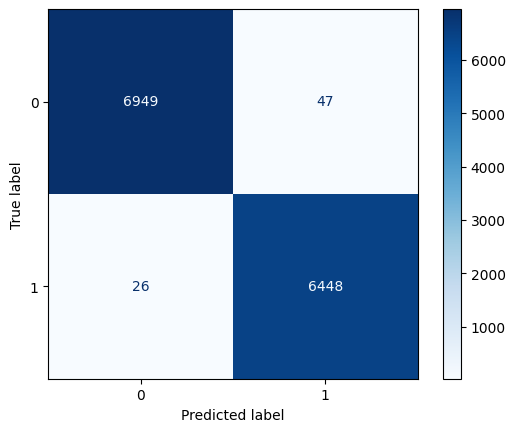

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.show()

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [79]:
rf.fit(x_train,y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   35.1s finished


RandomForestClassifier(n_jobs=-1, random_state=42, verbose=1)

In [80]:
accuracy_score(y_test,y_pred)

0.9945805493689681

In [81]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      6996
           1       0.99      1.00      0.99      6474

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



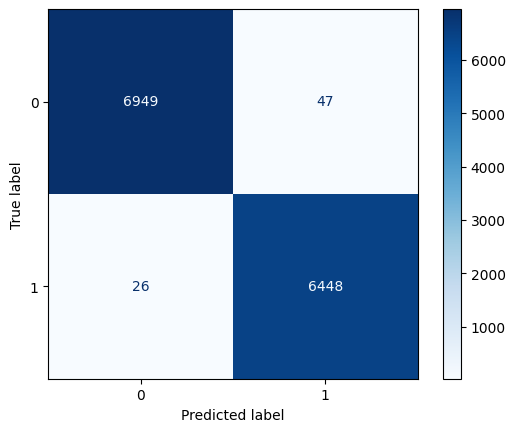

In [82]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap='Blues')
plt.show()

In [83]:
from sklearn.svm import LinearSVC
svm= LinearSVC(verbose=1)

In [84]:
svm.fit(x_train,y_train)
preds = svm.predict(x_test)
accuracy_score(y_test,preds)

[LibLinear]iter  1 act 2.572e+04 pre 2.426e+04 delta 7.558e-01 f 3.143e+04 |g| 1.575e+05 CG   7
cg reaches trust region boundary
iter  2 act 3.832e+03 pre 3.239e+03 delta 9.316e-01 f 5.706e+03 |g| 2.709e+04 CG  10
cg reaches trust region boundary
iter  3 act 1.297e+03 pre 1.127e+03 delta 1.107e+00 f 1.874e+03 |g| 1.089e+04 CG  15
cg reaches trust region boundary
iter  4 act 4.265e+02 pre 3.835e+02 delta 1.255e+00 f 5.767e+02 |g| 3.633e+03 CG  19
iter  5 act 1.126e+02 pre 1.178e+02 delta 1.255e+00 f 1.502e+02 |g| 1.448e+03 CG  29
iter  6 act 1.893e+01 pre 2.398e+01 delta 1.255e+00 f 3.760e+01 |g| 6.391e+02 CG  30
iter  7 act 5.738e+00 pre 6.258e+00 delta 1.255e+00 f 1.867e+01 |g| 3.533e+02 CG  15
iter  8 act -4.286e-01 pre 1.540e+00 delta 8.080e-02 f 1.293e+01 |g| 1.266e+02 CG  28
cg reaches trust region boundary
iter  8 act 7.043e-01 pre 1.089e+00 delta 5.970e-02 f 1.293e+01 |g| 1.266e+02 CG  16
cg reaches trust region boundary
iter  9 act 2.323e-01 pre 6.834e-01 delta 3.601e-02 f 1.22

0.9949517446176689

In [85]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      6996
           1       0.99      1.00      0.99      6474

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



In [86]:
from sklearn.svm import SVC

In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer


tf = TfidfVectorizer(max_features=10000, stop_words='english')

In [88]:
x_tf=tf.fit_transform(x).toarray()

In [89]:
x_train_tf,x_test_tf,y_train_tf,y_test_tf=train_test_split(x_tf,y,test_size=0.3,random_state=42)

In [90]:
lg_tf = LogisticRegression(max_iter=2000,verbose=1)

In [91]:
lg_tf.fit(x_train_tf,y_train_tf)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.3s finished


LogisticRegression(max_iter=2000, verbose=1)

In [92]:
y_pred_lg=lg_tf.predict(x_test_tf)

In [93]:

accuracy_score(y_test_tf,y_pred_lg)

0.9844097995545658

In [94]:
print(classification_report(y_test_tf,y_pred_lg))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      6996
           1       0.98      0.99      0.98      6474

    accuracy                           0.98     13470
   macro avg       0.98      0.98      0.98     13470
weighted avg       0.98      0.98      0.98     13470



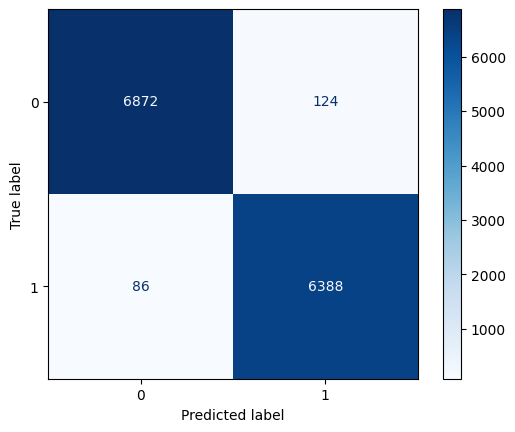

In [95]:
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_lg,cmap='Blues')
plt.show()

In [96]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   16.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   39.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s


0.9934669636228656


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.3s finished


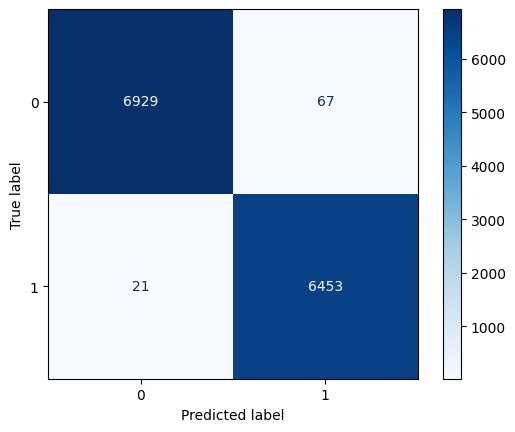

In [97]:
rf.fit(x_train_tf,y_train_tf)
y_pred_rf=rf.predict(x_test_tf)
print(accuracy_score(y_test_tf,y_pred_rf))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_rf,cmap="Blues")
plt.show()

In [98]:
from sklearn.tree import DecisionTreeClassifier

In [99]:
dt=DecisionTreeClassifier()

In [100]:
dt.fit(x_train_tf,y_train_tf)

DecisionTreeClassifier()

In [101]:
y_pred_dt=dt.predict(x_test_tf)

0.9942835931700075
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6996
           1       1.00      0.99      0.99      6474

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



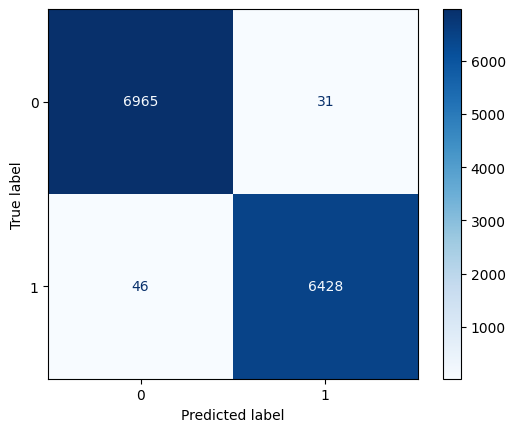

In [102]:
print(accuracy_score(y_test_tf,y_pred_dt))
print(classification_report(y_test_tf,y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_dt,cmap="Blues")
plt.show()

In [103]:
!pip install lightgbm

In [104]:
import lightgbm as lgb

In [105]:
lgbm = lgb.LGBMClassifier(verbose=1)


[LightGBM] [Info] Number of positive: 14943, number of negative: 16485
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.671786 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765136
[LightGBM] [Info] Number of data points in the train set: 31428, number of used features: 9876
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475468 -> initscore=-0.098208
[LightGBM] [Info] Start training from score -0.098208


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9969561989606534
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6996
           1       1.00      1.00      1.00      6474

    accuracy                           1.00     13470
   macro avg       1.00      1.00      1.00     13470
weighted avg       1.00      1.00      1.00     13470



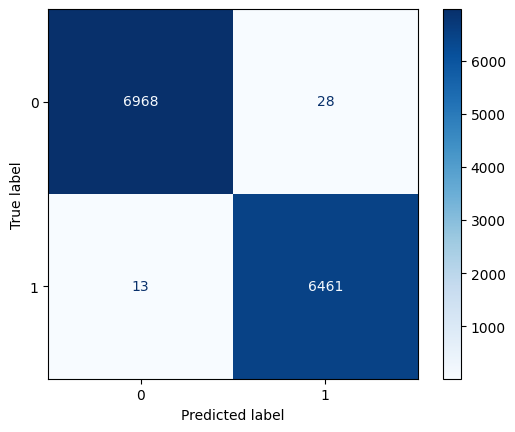

In [106]:
lgbm.fit(x_train_tf, y_train_tf)
y_pred_lgbm=lgbm.predict(x_test_tf)
print(accuracy_score(y_test_tf,y_pred_lgbm))
print(classification_report(y_test_tf,y_pred_lgbm))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_lgbm,cmap="Blues")
plt.show()

In [107]:
!pip install catboost

In [108]:
from catboost import CatBoostClassifier

0:	learn: 0.9910271	total: 1.16s	remaining: 9m 36s
1:	learn: 0.9905816	total: 1.92s	remaining: 7m 56s
2:	learn: 0.9906135	total: 2.68s	remaining: 7m 24s
3:	learn: 0.9917271	total: 3.44s	remaining: 7m 7s
4:	learn: 0.9912817	total: 4.27s	remaining: 7m 2s
5:	learn: 0.9911544	total: 5.04s	remaining: 6m 55s
6:	learn: 0.9912817	total: 5.81s	remaining: 6m 49s
7:	learn: 0.9914089	total: 6.58s	remaining: 6m 44s
8:	learn: 0.9914726	total: 7.34s	remaining: 6m 40s
9:	learn: 0.9916953	total: 8.1s	remaining: 6m 37s
10:	learn: 0.9922999	total: 8.87s	remaining: 6m 34s
11:	learn: 0.9926180	total: 9.65s	remaining: 6m 32s
12:	learn: 0.9927453	total: 10.4s	remaining: 6m 29s
13:	learn: 0.9928408	total: 11.2s	remaining: 6m 28s
14:	learn: 0.9931590	total: 12s	remaining: 6m 26s
15:	learn: 0.9932544	total: 12.7s	remaining: 6m 25s
16:	learn: 0.9933499	total: 13.5s	remaining: 6m 23s
17:	learn: 0.9934772	total: 14.4s	remaining: 6m 25s
18:	learn: 0.9935090	total: 15.2s	remaining: 6m 23s
19:	learn: 0.9935726	total:

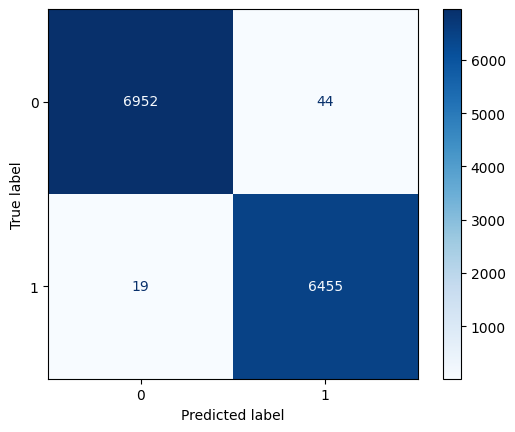

In [109]:
 model =  CatBoostClassifier(
    iterations=500,     # maximum number of trees
    learning_rate=0.05,  # smaller rate may need more iterations
    depth=6,             # depth of each tree
    eval_metric='Accuracy',
    random_seed=42
)
model.fit(x_train_tf, y_train_tf)
y_pred_cat=model.predict(x_test_tf)
print(accuracy_score(y_test_tf,y_pred_cat))
print(classification_report(y_test_tf,y_pred_cat))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_cat,cmap="Blues")
plt.show()

In [110]:
from sklearn.ensemble import GradientBoostingClassifier

In [111]:
gbc = GradientBoostingClassifier(
    n_estimators=100,   # Number of trees
    learning_rate=0.1,  # Step size
    max_depth=3,        # Depth of each tree
    random_state=42,
    verbose=1
)

      Iter       Train Loss   Remaining Time 
         1           1.1986           22.04m
         2           1.0469           21.77m
         3           0.9204           21.55m
         4           0.8136           21.35m
         5           0.7224           21.09m
         6           0.6439           20.87m
         7           0.5759           20.65m
         8           0.5167           20.43m
         9           0.4648           20.24m
        10           0.4192           20.04m
        20           0.1689           17.84m
        30           0.0856           15.62m
        40           0.0569           13.38m
        50           0.0461           11.15m
        60           0.0418            8.94m
        70           0.0378            6.71m
        80           0.0351            4.48m
        90           0.0322            2.24m
       100           0.0305            0.00s
0.9944320712694877
              precision    recall  f1-score   support

           0       1.00  

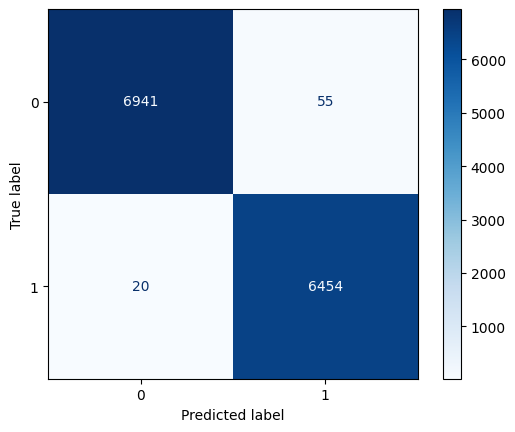

In [112]:
gbc.fit(x_train_tf,y_train_tf)
y_pred_gbc=gbc.predict(x_test_tf)
print(accuracy_score(y_test_tf,y_pred_gbc))
print(classification_report(y_test_tf,y_pred_gbc))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_gbc,cmap="Blues")
plt.show()

[LibLinear]iter  1 act 2.633e+04 pre 2.538e+04 delta 1.374e+01 f 3.143e+04 |g| 5.425e+03 CG   4
cg reaches trust region boundary
iter  2 act 2.914e+03 pre 2.552e+03 delta 1.633e+01 f 5.097e+03 |g| 7.949e+02 CG   7
iter  3 act 8.573e+02 pre 7.811e+02 delta 1.797e+01 f 2.182e+03 |g| 2.360e+02 CG  15
iter  4 act 1.067e+02 pre 9.676e+01 delta 1.797e+01 f 1.325e+03 |g| 1.262e+02 CG  11
iter  5 act 1.809e+01 pre 1.757e+01 delta 1.797e+01 f 1.218e+03 |g| 2.503e+01 CG  15
iter  6 act 1.104e+00 pre 1.098e+00 delta 1.797e+01 f 1.200e+03 |g| 3.663e+00 CG  17
iter  7 act 1.522e-02 pre 1.522e-02 delta 1.797e+01 f 1.199e+03 |g| 4.841e-01 CG  17
0.9924276169265034


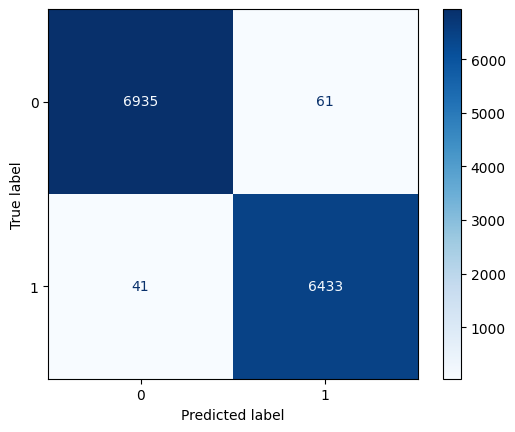

In [113]:
svm= LinearSVC(verbose=1)
svm.fit(x_train_tf,y_train_tf)
preds = svm.predict(x_test_tf)
print(accuracy_score(y_test_tf,preds))
ConfusionMatrixDisplay.from_predictions(y_test_tf,preds,cmap="Blues")
plt.show()

In [116]:
!pip install gensim

In [117]:
import gensim
print(gensim.__version__)

4.4.0


In [118]:
from gensim.models import Word2Vec

In [122]:
sentences = data['corrected'].apply(lambda x: x.split()).tolist()

In [123]:
model = Word2Vec(
    sentences=sentences,
    vector_size=300,   # embedding dimension
    window=5,          # context window
    min_count=2,       # ignore rare words
    sg=0,              # 1 = Skip-Gram, 0 = CBOW
    workers=-1,         # parallel threads
    epochs=10
)

In [124]:
model.save("word2vec_model.model")

In [125]:
words = list(model.wv.index_to_key)
print(words[:2])

['say', 'trump']


In [127]:
vector = model.wv['say']  # 'example' must be in your vocabulary
print(vector.shape)

(300,)


In [128]:
import numpy as np

def document_vector(tokens):

    tokens = [word for word in tokens if word in model.wv.index_to_key]
    if len(tokens) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[tokens], axis=0)


X = np.array([document_vector(tokens) for tokens in sentences])

In [129]:
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X, y, test_size=0.3, random_state=42)

0.5193763919821827
              precision    recall  f1-score   support

           0       0.52      1.00      0.68      6996
           1       0.00      0.00      0.00      6474

    accuracy                           0.52     13470
   macro avg       0.26      0.50      0.34     13470
weighted avg       0.27      0.52      0.36     13470



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

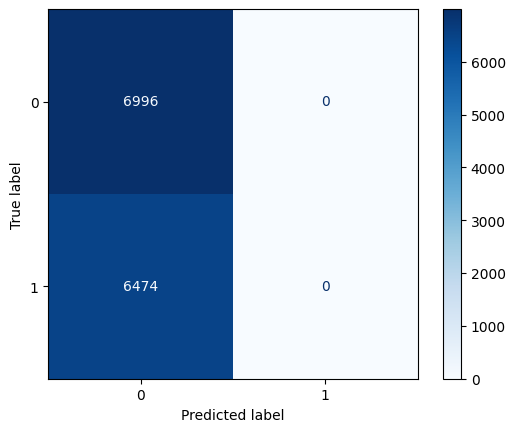

In [131]:
lg_w=LogisticRegression(max_iter=2000,verbose=1)
lg_w.fit(X_train_w,y_train_w)
y_pred_lg=lg_w.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_lg))
print(classification_report(y_test_w,y_pred_lg))
ConfusionMatrixDisplay.from_predictions(y_test_w,y_pred_lg,cmap="Blues")
plt.show()

In [132]:
rf_w = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   28.8s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


0.9206384558277654
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      6996
           1       0.93      0.90      0.92      6474

    accuracy                           0.92     13470
   macro avg       0.92      0.92      0.92     13470
weighted avg       0.92      0.92      0.92     13470



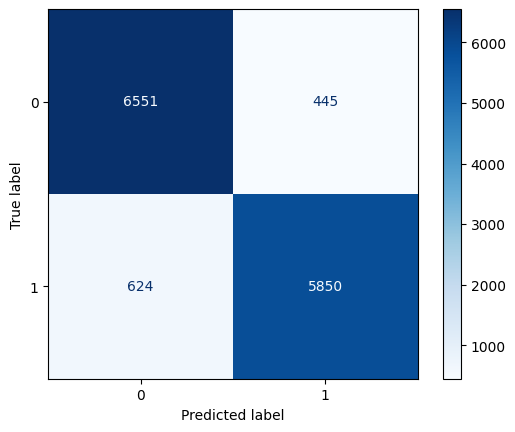

In [133]:
rf_w.fit(X_train_w,y_train_w)
y_pred_rf_w=rf_w.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_rf_w))
print(classification_report(y_test_w,y_pred_rf_w))
ConfusionMatrixDisplay.from_predictions(y_test_w,y_pred_rf_w,cmap="Blues")
plt.show()

[LightGBM] [Info] Number of positive: 14943, number of negative: 16485
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.077730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 31428, number of used features: 300
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475468 -> initscore=-0.098208
[LightGBM] [Info] Start training from score -0.098208


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9208611729769859
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      6996
           1       0.92      0.91      0.92      6474

    accuracy                           0.92     13470
   macro avg       0.92      0.92      0.92     13470
weighted avg       0.92      0.92      0.92     13470



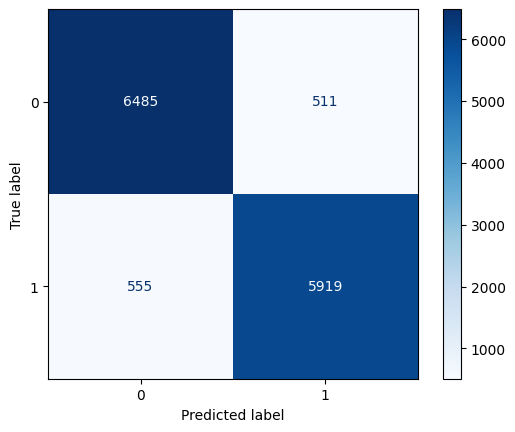

In [134]:
lgbm.fit(X_train_w,y_train_w)
y_pred_lgbm=lgbm.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_lgbm))
print(classification_report(y_test_w,y_pred_lgbm))
ConfusionMatrixDisplay.from_predictions(y_test_w,y_pred_lgbm,cmap="Blues")
plt.show()

Learning rate set to 0.044904
0:	learn: 0.6754056	total: 78.2ms	remaining: 1m 18s
1:	learn: 0.6599663	total: 145ms	remaining: 1m 12s
2:	learn: 0.6446891	total: 207ms	remaining: 1m 8s
3:	learn: 0.6306166	total: 271ms	remaining: 1m 7s
4:	learn: 0.6187715	total: 333ms	remaining: 1m 6s
5:	learn: 0.6073560	total: 397ms	remaining: 1m 5s
6:	learn: 0.5955217	total: 458ms	remaining: 1m 5s
7:	learn: 0.5858708	total: 522ms	remaining: 1m 4s
8:	learn: 0.5765936	total: 582ms	remaining: 1m 4s
9:	learn: 0.5670555	total: 646ms	remaining: 1m 3s
10:	learn: 0.5584159	total: 710ms	remaining: 1m 3s
11:	learn: 0.5503012	total: 772ms	remaining: 1m 3s
12:	learn: 0.5428118	total: 836ms	remaining: 1m 3s
13:	learn: 0.5353831	total: 900ms	remaining: 1m 3s
14:	learn: 0.5285230	total: 963ms	remaining: 1m 3s
15:	learn: 0.5222888	total: 1.02s	remaining: 1m 2s
16:	learn: 0.5161404	total: 1.09s	remaining: 1m 2s
17:	learn: 0.5102613	total: 1.15s	remaining: 1m 2s
18:	learn: 0.5043766	total: 1.21s	remaining: 1m 2s
19:	lear

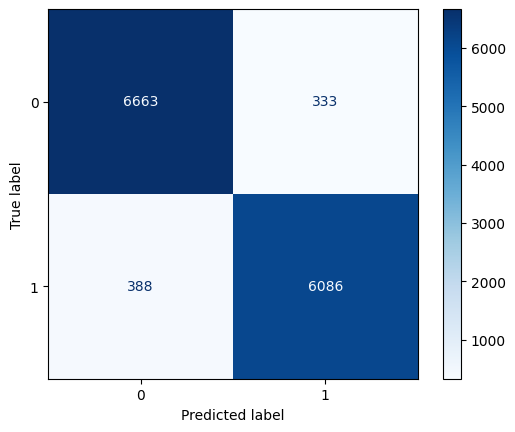

In [135]:
model = CatBoostClassifier(verbose=1)
model.fit(X_train_w,y_train_w)
y_pred_cat=model.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_cat))
print(classification_report(y_test_w,y_pred_cat))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_cat,cmap="Blues")
plt.show()

      Iter       Train Loss   Remaining Time 
         1           1.3427            8.86m
         2           1.3064            8.72m
         3           1.2744            8.69m
         4           1.2445            8.58m
         5           1.2165            8.44m
         6           1.1912            8.32m
         7           1.1679            8.29m
         8           1.1449            8.22m
         9           1.1245            8.14m
        10           1.1048            8.05m
        20           0.9562            7.22m
        30           0.8563            6.35m
        40           0.7837            5.45m
        50           0.7250            4.55m
        60           0.6767            3.64m
        70           0.6371            2.73m
        80           0.6034            1.83m
        90           0.5745           54.80s
       100           0.5490            0.00s
0.8958426132145508
              precision    recall  f1-score   support

           0       0.90  

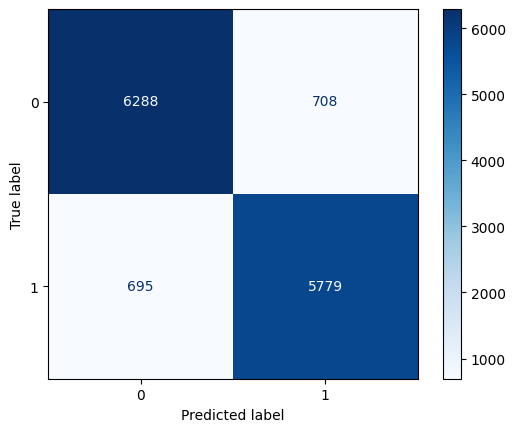

In [136]:
gbc.fit(X_train_w,y_train_w)
y_pred_gbcw=gbc.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_gbcw))
print(classification_report(y_test_w,y_pred_gbcw))
ConfusionMatrixDisplay.from_predictions(y_test_w,y_pred_gbcw,cmap="Blues")
plt.show()

In [137]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('xlm-r-distilroberta-base-paraphrase-v1')
embeddings = model.encode(x.astype(str).tolist(), show_progress_bar=True)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1404 [00:00<?, ?it/s]

In [138]:
X = embeddings

In [139]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y, test_size=0.2, random_state=42)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.8s finished


0.9792873051224944


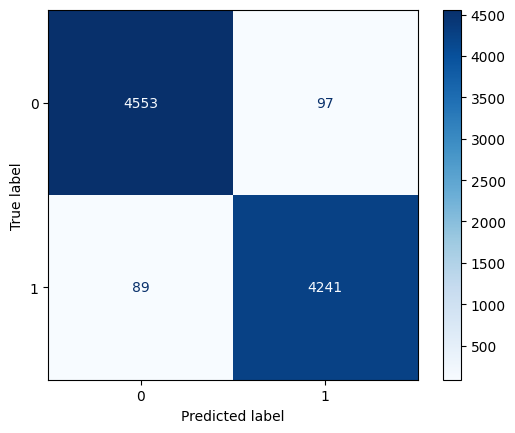

In [140]:
lg_tf = LogisticRegression(max_iter=2000,verbose=1)
lg_tf.fit(X_train_b,y_train_b)
y_pred_b=lg_tf.predict(X_test_b)
print(accuracy_score(y_test_b,y_pred_b))
ConfusionMatrixDisplay.from_predictions(y_test_b,y_pred_b,cmap="Blues")
plt.show()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   28.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.1min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


0.9389755011135857


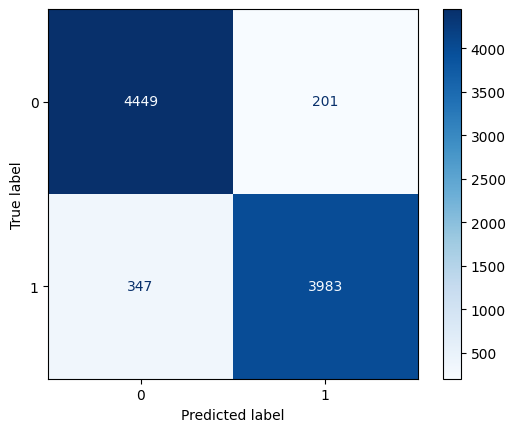

In [142]:
rf.fit(X_train_b,y_train_b)
y_pred_b=rf.predict(X_test_b)
print(accuracy_score(y_test_b,y_pred_b))
ConfusionMatrixDisplay.from_predictions(y_test_b,y_pred_b,cmap="Blues")
plt.show()

0.8537861915367483


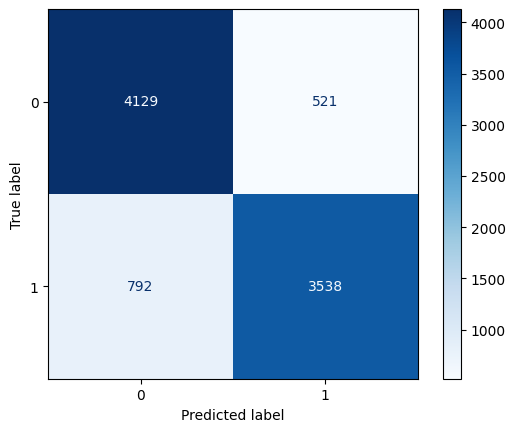

In [143]:
dt.fit(X_train_b,y_train_b)
y_pred_b=dt.predict(X_test_b)
print(accuracy_score(y_test_b,y_pred_b))
ConfusionMatrixDisplay.from_predictions(y_test_b,y_pred_b,cmap="Blues")
plt.show()


[LightGBM] [Info] Number of positive: 17087, number of negative: 18831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.236076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 35918, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475722 -> initscore=-0.097187
[LightGBM] [Info] Start training from score -0.097187
0.9510022271714922
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4650
           1       0.95      0.94      0.95      4330

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


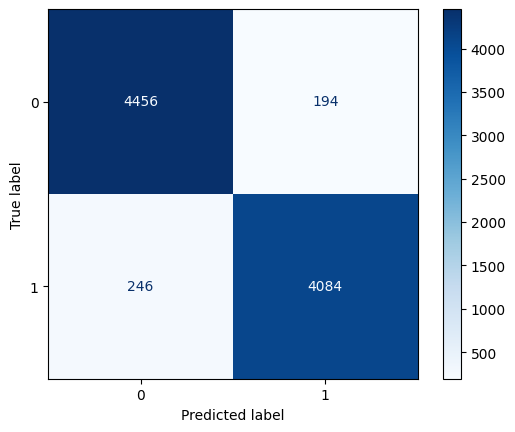

In [144]:
lgbm.fit(X_train_b,y_train_b)
y_pred_lgbm=lgbm.predict(X_test_b)
print(accuracy_score(y_test_b,y_pred_lgbm))
print(classification_report(y_test_b,y_pred_lgbm))
ConfusionMatrixDisplay.from_predictions(y_test_b,y_pred_lgbm,cmap="Blues")
plt.show()

Learning rate set to 0.047539
0:	learn: 0.6589286	total: 208ms	remaining: 3m 27s
1:	learn: 0.6287737	total: 383ms	remaining: 3m 10s
2:	learn: 0.6026031	total: 549ms	remaining: 3m 2s
3:	learn: 0.5775077	total: 711ms	remaining: 2m 56s
4:	learn: 0.5544220	total: 874ms	remaining: 2m 53s
5:	learn: 0.5337503	total: 1.04s	remaining: 2m 52s
6:	learn: 0.5160835	total: 1.2s	remaining: 2m 49s
7:	learn: 0.4995623	total: 1.35s	remaining: 2m 48s
8:	learn: 0.4865444	total: 1.51s	remaining: 2m 46s
9:	learn: 0.4724127	total: 1.68s	remaining: 2m 46s
10:	learn: 0.4605284	total: 1.83s	remaining: 2m 44s
11:	learn: 0.4485755	total: 1.99s	remaining: 2m 43s
12:	learn: 0.4377843	total: 2.15s	remaining: 2m 43s
13:	learn: 0.4277049	total: 2.31s	remaining: 2m 42s
14:	learn: 0.4176230	total: 2.46s	remaining: 2m 41s
15:	learn: 0.4095555	total: 2.62s	remaining: 2m 41s
16:	learn: 0.4016730	total: 2.79s	remaining: 2m 41s
17:	learn: 0.3944539	total: 2.94s	remaining: 2m 40s
18:	learn: 0.3877008	total: 3.1s	remaining: 2m

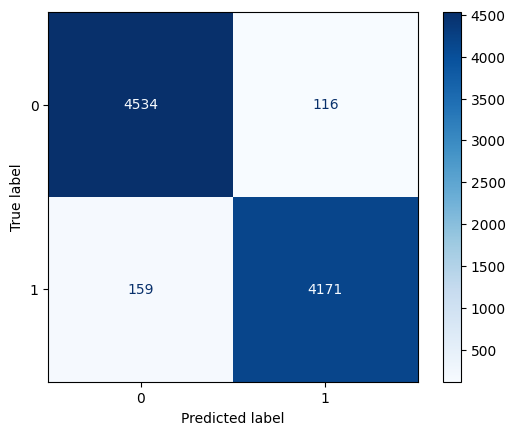

In [145]:
model = CatBoostClassifier(verbose=1)
model.fit(X_train_b,y_train_b)
y_pred_cat=model.predict(X_test_b)
print(accuracy_score(y_test_b,y_pred_cat))
print(classification_report(y_test_b,y_pred_cat))
ConfusionMatrixDisplay.from_predictions(y_test_b,y_pred_cat,cmap="Blues")
plt.show()

In [ ]:
gbc.fit(X_train_b,y_train_b)
y_pred_gbcw=gbc.predict(X_test_b)
print(accuracy_score(y_test_b,y_pred_gbcw))
print(classification_report(y_test_b,y_pred_gbcw))
ConfusionMatrixDisplay.from_predictions(y_test_,y_pred_gbcw,cmap="Blues")
plt.show()

In [ ]:
from sklearn.model_selection import StartifiedKFold

In [ ]:
skf=StartifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=[]

In [ ]:
for train_idx,val_idx in skf.split(X,y):
    X_train,X_test=X[],X[]
    y_train,y_test=y[],y[]
    lg_tf.fit(X_train,y_train)
    preds=lg_tf.predict(X_test)
    score=accuracy_score(y_test,preds)
    scores.append(score)
print("fold scores",scores)
print("mean score is",np.mean(scores))
